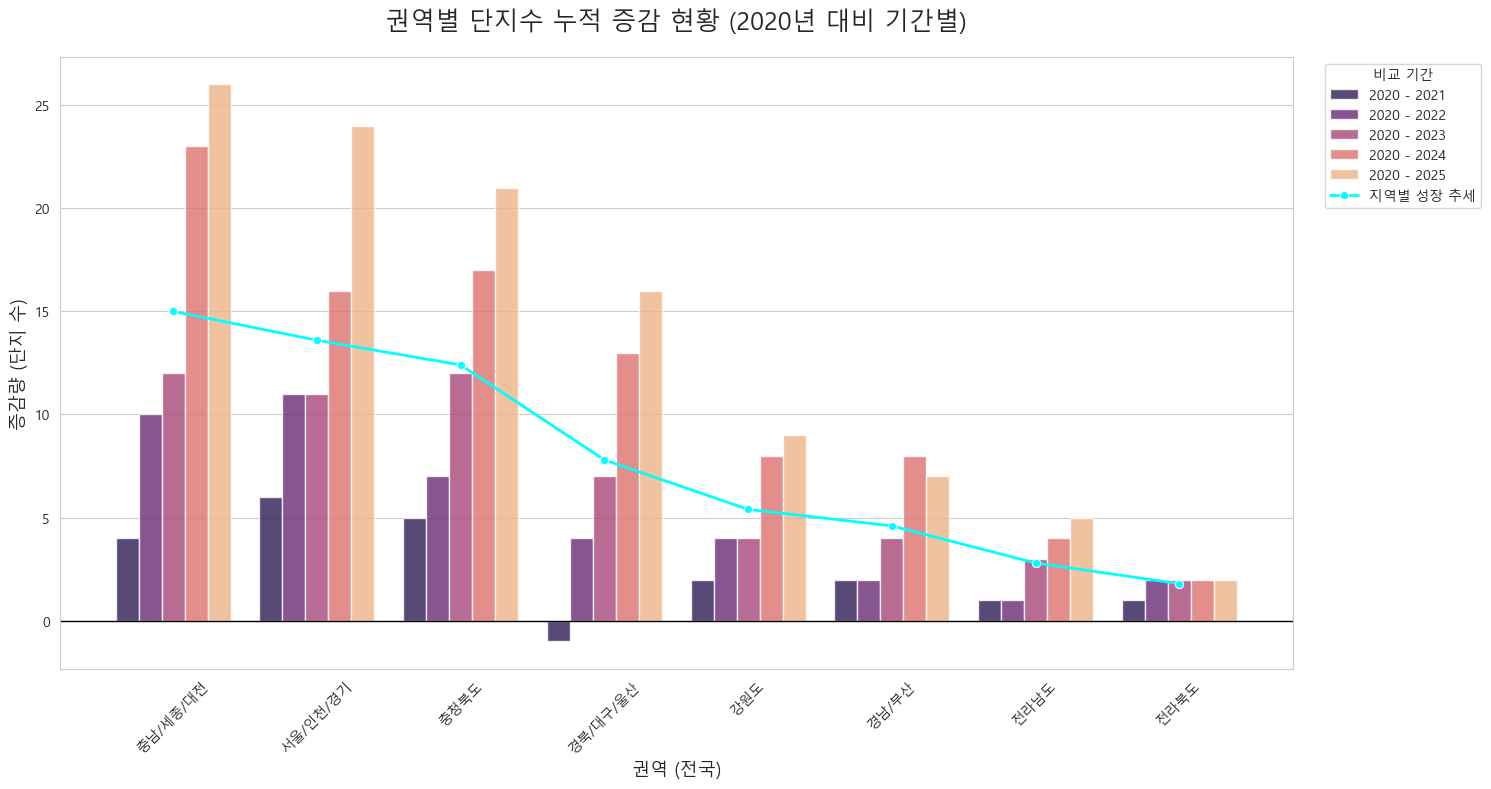

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. 데이터 불러오기
df = pd.read_csv('권역별_단지수_통합현황.csv')
df_indexed = df.set_index('전국') # 전국을 인덱스로 정함

# 2. 기간별 증감치 계산 (예: 2020-2021, 2020-2022 ...)
years = ['2021년', '2022년', '2023년', '2024년', '2025년'] # 계산할 연도
diff_data = {} # 딕셔너리

for year in years:
    label = f"2020 - {year.replace('년', '')}" # '2020 - 2021' 형식 생성
    diff_data[label] = df_indexed[year] - df_indexed['2020년'] # 증감 계산

diff_df = pd.DataFrame(diff_data) # 데이터프레임 변환

# 3. 정렬 로직 (마지막 기간인 '2020-2025' 증감치 기준 내림차순)
last_period = diff_df.columns[-1]
sorted_regions = diff_df.sort_values(by=last_period, ascending=False).index.tolist()

# 시각화를 위한 데이터 재구성
plot_df = diff_df.reset_index().melt(id_vars='전국', var_name='기간', value_name='증감치')

# 4. 그래프 그리기
plt.figure(figsize=(15, 8))
sns.set_style("whitegrid")
plt.rc('font', family='Malgun Gothic')

# [막대 그래프] x축: 전국, 구분(hue): 기간
sns.barplot(
    data=plot_df, 
    x='전국', 
    y='증감치', 
    hue='기간', 
    palette='magma', 
    alpha=0.8,
    order=sorted_regions
)

# [선 그래프] 지역별 평균 추세선 (막대 중앙 관통)
sns.lineplot(
    data=plot_df, 
    x='전국', 
    y='증감치', 
    color='cyan', 
    marker='o', 
    linewidth=2, 
    label='지역별 성장 추세',
    errorbar=None,
    sort=True
)

# 5. 그래프 세부 설정
plt.title('권역별 단지수 누적 증감 현황 (2020년 대비 기간별)', fontsize=18, pad=20)
plt.xlabel('권역 (전국)', fontsize=13)
plt.ylabel('증감량 (단지 수)', fontsize=13)
plt.xticks(rotation=45)
plt.axhline(0, color='black', linewidth=1)

plt.legend(title='비교 기간', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()